# 04: Policy Value and Uncertainty

## Aim

Recall that notebook 03 compared several customer-targeting strategies using observed retention uplift.

This notebook will explore two follow-up questions:

1. **How uncertain are those policy results?**
2. **What do those results mean in practical terms?**

The goal here is to move from model scores to a simple decision framework using confidence intervals, expected retained customers, and treatment economics.

In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import PercentFormatter

RANDOM_STATE = 42

## 1. Recreate the targeting-policy results

I first begin with the same policy comparison used in Notebook 03.

Each strategy ranks customers differently. At each targeting "budget" we select the highest-ranked customers and measure the following:

`control churn - treatment churn`

Note that positive values mean the treatment *reduced* churn inside the targeted group.

The next step will then add uncertainty around these point estimates using `bootstrap resampling`.

In [2]:
# First I'll load the evaluation results created in Notebook 03
eval_results = pd.read_csv(
    "../artifacts/causal_eval_results.csv"
)

print("Evaluation customers:", len(eval_results))
print("Columns:", eval_results.columns.tolist())

eval_results.head()

Evaluation customers: 2974
Columns: ['y', 'treatment', 'predicted_churn_risk', 'predicted_t_uplift', 'predicted_dr_uplift', 'predicted_cf_uplift']


,y,treatment,predicted_churn_risk,predicted_t_uplift,predicted_dr_uplift,predicted_cf_uplift
0,0,0,0.000402,0.017658,0.003405,-0.002576
1,0,0,0.004623,0.013191,-0.011516,0.000270
2,1,0,0.000641,0.029354,0.020914,0.010355
3,0,1,0.000223,0.002801,-0.005151,0.002260
4,0,1,0.000055,0.038314,0.058733,0.002657


**Approach:** recreate the policy results from Notebook 03 so we have the same baseline point estimates before adding bootstrap uncertainty.

In [3]:
# target the same user shares used in Notebook 03
policy_budgets = [0.05, 0.10, 0.20, 0.30, 0.50]

policy_columns = {
    "Churn risk": "predicted_churn_risk",
    "T-Learner": "predicted_t_uplift",
    "DRLearner": "predicted_dr_uplift",
    "CausalForestDML": "predicted_cf_uplift"
}

policy_rows = []

for fraction in policy_budgets:
    n_target = int(len(eval_results) * fraction)

    row = {
        "Targeting fraction": fraction,
        "Customers targeted": n_target
    }

    # target the highest ranked customers for each policy
    for policy_name, score_col in policy_columns.items():
        targeted = eval_results.nlargest(
            n_target,
            score_col
        )

        control_rate = targeted.loc[
            targeted["treatment"] == 0,
            "y"
        ].mean()

        treatment_rate = targeted.loc[
            targeted["treatment"] == 1,
            "y"
        ].mean()

        row[policy_name] = control_rate - treatment_rate

    # repeated random samples as benchmark
    random_uplifts = []

    for seed in range(250):
        targeted = eval_results.sample(
            n=n_target,
            random_state=seed
        )

        control_rate = targeted.loc[
            targeted["treatment"] == 0,
            "y"
        ].mean()

        treatment_rate = targeted.loc[
            targeted["treatment"] == 1,
            "y"
        ].mean()

        random_uplifts.append(
            control_rate - treatment_rate
        )

    row["Random"] = np.nanmean(random_uplifts)

    policy_rows.append(row)

policy_comparison = pd.DataFrame(policy_rows)

policy_comparison

,Targeting fraction,Customers targeted,Churn risk,T-Learner,DRLearner,CausalForestDML,Random
0,0.05,148,0.091847,0.035352,0.041466,-0.038978,0.003507
1,0.10,297,0.027515,0.017917,-0.005045,-0.028984,0.003708
2,0.20,594,0.027972,0.007778,0.014223,-0.008547,0.003187
3,0.30,892,0.021286,0.005100,0.014459,-0.002809,0.003610
4,0.50,1487,0.025063,0.003682,0.007502,0.001610,0.003499


**Results:** We got the same baseline results

## 2. Add uncertainty with bootstrap resampling

The point estimates show which policies performed best in this sample. However, they do not show how *stable* those results are.

So, we can estimate *uncertainty*. Here I will use bootstrap resampling. This involves repeatedly sampling customers with replacement from the evaluation data and then recalculating the retention uplift for each targeting policy.

This should give us a distribution of possible policy values and lets us calculate 95% confidence intervals around the original estimates.

In [5]:
# this code will give us a row per policy x targeting budget -- will have pointe estimate and 95% bootsrap interval

# bootstrap each policy estimate to measure uncertainty
bootstrap_rows = []

n_bootstrap = 1000
rng = np.random.default_rng(RANDOM_STATE)

for fraction in policy_budgets:
    n_target = int(len(eval_results) * fraction)

    for policy_name, score_col in policy_columns.items():
        bootstrap_uplifts = []

        # re-sample using replacement
        for _ in range(n_bootstrap):
            sample = eval_results.sample(
                n=len(eval_results),
                replace=True,
                random_state=int(rng.integers(0, 1_000_000))
            )

            targeted = sample.nlargest(
                n_target,
                score_col
            )

            control_rate = targeted.loc[
                targeted["treatment"] == 0,
                "y"
            ].mean()

            treatment_rate = targeted.loc[
                targeted["treatment"] == 1,
                "y"
            ].mean()

            bootstrap_uplifts.append(
                control_rate - treatment_rate
            )

        # use the middle 95% of bootstrap estimates as the confidence interval: upper = 97.5 and lower = 2.5
        lower_ci, upper_ci = np.nanpercentile(
            bootstrap_uplifts,
            [2.5, 97.5]
        )

        point_estimate = policy_comparison.loc[
            policy_comparison["Targeting fraction"] == fraction,
            policy_name
        ].iloc[0]

        bootstrap_rows.append({
            "Targeting fraction": fraction,
            "Policy": policy_name,
            "Point estimate": point_estimate,
            "Lower 95% CI": lower_ci,
            "Upper 95% CI": upper_ci
        })

bootstrap_results = pd.DataFrame(bootstrap_rows)

bootstrap_results

,Targeting fraction,Policy,Point estimate,Lower 95% CI,Upper 95% CI
0,0.05,Churn risk,0.091847,-0.048229,0.225264
1,0.05,T-Learner,0.035352,-0.051293,0.145287
2,0.05,DRLearner,0.041466,-0.053583,0.159990
3,0.05,CausalForestDML,-0.038978,-0.110171,0.082602
4,0.10,Churn risk,0.027515,-0.066383,0.129450
5,0.10,T-Learner,0.017917,-0.030910,0.076942
6,0.10,DRLearner,-0.005045,-0.053339,0.052506
7,0.10,CausalForestDML,-0.028984,-0.086897,0.045402
8,0.20,Churn risk,0.027972,-0.028220,0.090582
9,0.20,T-Learner,0.007778,-0.018711,0.039170


### Bootstrap results

The confidence intervals are wide, especially at the smaller targeting budgets. Note that every 95% interval crosses zero.

This means we should be cautious when interpreting the original point estimates. For example, our churn risk targeting has a large observed uplift at the top 5%, but the small number of targeted customers creates a lot of uncertainty.

But as the targeting budget increases the estimates generally look more stable. That is because more customers are included.

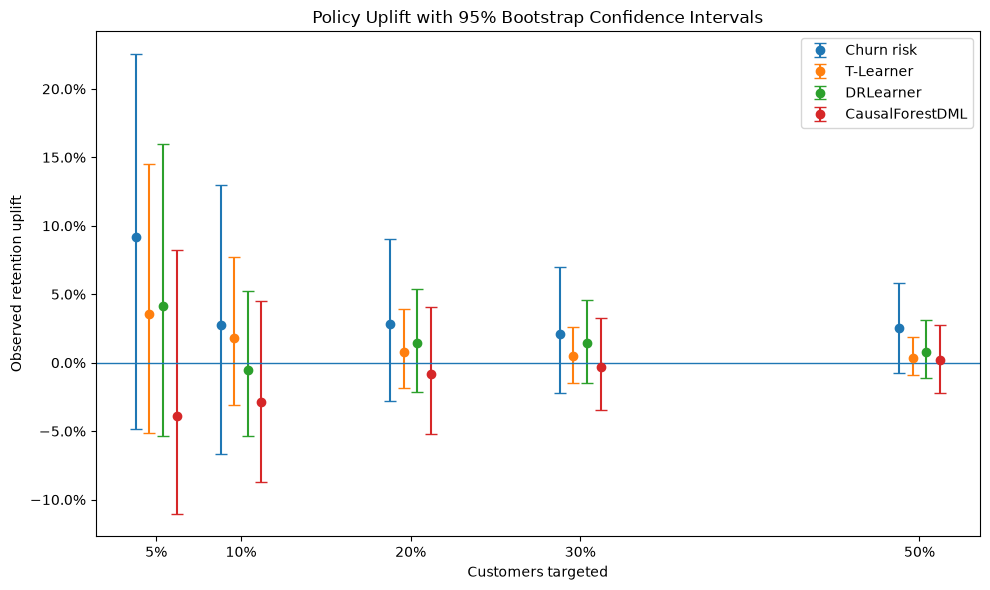

In [7]:
# make an error bar plot
# we can plot the point estimates with 95% bootstrap confidence intervals

plot_data = bootstrap_results.copy()
plot_data["Targeting fraction"] = plot_data["Targeting fraction"] * 100

plt.figure(figsize=(10, 6))

policies = list(policy_columns.keys())
offsets = [-1.2, -0.4, 0.4, 1.2]

for policy, offset in zip(policies, offsets):
    policy_data = plot_data[
        plot_data["Policy"] == policy
    ]

    x = policy_data["Targeting fraction"] + offset

    yerr = np.vstack([
        policy_data["Point estimate"] - policy_data["Lower 95% CI"],
        policy_data["Upper 95% CI"] - policy_data["Point estimate"]
    ])

    plt.errorbar(
        x,
        policy_data["Point estimate"],
        yerr=yerr,
        fmt="o",
        capsize=4,
        label=policy
    )

plt.axhline(0, linewidth=1)
plt.xticks(
    [5, 10, 20, 30, 50],
    ["5%", "10%", "20%", "30%", "50%"]
)

plt.xlabel("Customers targeted")
plt.ylabel("Observed retention uplift")
plt.title("Policy Uplift with 95% Bootstrap Confidence Intervals")

plt.gca().yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

plt.legend()
plt.tight_layout()
plt.show()

## 3. Translate uplift into retained customers

Retention uplift is likely easier to interpret when translated into an expected number of customers retained.

So, for each policy and targeting budget, I will convert the observed uplift into:

`additional retained customers per 1,000 targeted`

This should give us a more practical view of the potential impact of each strategy.

In [8]:
# convert uplift into expected retained customers per 1,000 targeted
retained_customers = policy_comparison.copy()

for policy in [
    "Churn risk",
    "T-Learner",
    "DRLearner",
    "CausalForestDML",
    "Random"
]:
    retained_customers[policy] = (
        retained_customers[policy] * 1000
    )

retained_customers

,Targeting fraction,Customers targeted,Churn risk,T-Learner,DRLearner,CausalForestDML,Random
0,0.05,148,91.847265,35.352072,41.466498,-38.978495,3.506942
1,0.10,297,27.514601,17.916774,-5.045045,-28.984475,3.707631
2,0.20,594,27.972028,7.777778,14.222782,-8.547009,3.186993
3,0.30,892,21.285629,5.099846,14.458534,-2.809071,3.609709
4,0.50,1487,25.062896,3.681634,7.502266,1.609901,3.498665


### Interpretation

Expressed per 1,000 targeted customers, churn-risk targeting has the largest estimated impact across all targeting budgets.

For example:

- targeting the top 5% corresponds to about 92 additional retained customers per 1,000 targeted
- targeting the top 20% corresponds to about 28 additional retained customers per 1,000 targeted
- targeting the top 50% corresponds to about 25 additional retained customers per 1,000 targeted

However, these numbers are still based on the same point estimates calculated earlier, so the bootstrap uncertainty still applies.

## 4. Business value example

A targeting policy is useful if the expected retention benefit is worth the cost of the intervention.

So, to make the results easier to interpret, we can use a simple example:

- value of retaining one customer: `$100`
- cost of treating one customer: `$2`

These values are used here to illustrative the approach. The goal is to show how model results can be translated into a practical decision. The following will answer the question: 
> If we targeted 1,000 custoemrs, then what would the estimated net value be under our assumptions?

In [9]:
# our business assumptions
value_per_retained_customer = 100
treatment_cost_per_customer = 2

business_value = retained_customers.copy()

for policy in [
    "Churn risk",
    "T-Learner",
    "DRLearner",
    "CausalForestDML",
    "Random"
]:
    # expected value per 1,000 targeted customers
    retained_value = (
        business_value[policy] * value_per_retained_customer
    )

    treatment_cost = (
        1000 * treatment_cost_per_customer
    )

    business_value[policy] = (
        retained_value - treatment_cost
    )

business_value

,Targeting fraction,Customers targeted,Churn risk,T-Learner,DRLearner,CausalForestDML,Random
0,0.05,148,7184.726522,1535.207186,2146.649810,-5897.849462,-1649.305770
1,0.10,297,751.460091,-208.322630,-2504.504505,-4898.447515,-1629.236926
2,0.20,594,797.202797,-1222.222222,-577.721838,-2854.700855,-1681.300651
3,0.30,892,128.562937,-1490.015361,-554.146567,-2280.907053,-1639.029115
4,0.50,1487,506.289609,-1631.836604,-1249.773356,-1839.009949,-1650.133497


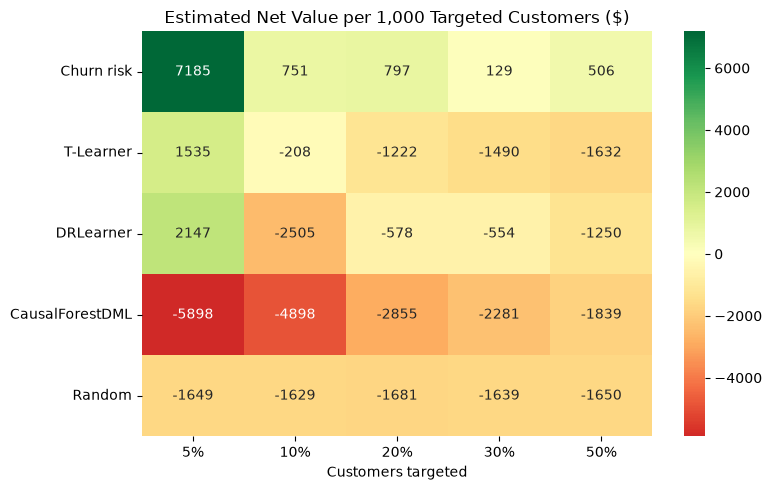

In [10]:
# make heatmap to show estimated net value per 1,0000 targeted
value_heatmap = (
    business_value
    .set_index("Targeting fraction")[
        [
            "Churn risk",
            "T-Learner",
            "DRLearner",
            "CausalForestDML",
            "Random"
        ]
    ]
    .T
)

value_heatmap.columns = [
    f"{int(fraction * 100)}%"
    for fraction in value_heatmap.columns
]

plt.figure(figsize=(8, 5))

sns.heatmap(
    value_heatmap,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    center=0
)

plt.xlabel("Customers targeted")
plt.ylabel("")
plt.title("Estimated Net Value per 1,000 Targeted Customers ($)")
plt.tight_layout()
plt.show()

## 5. Summary

The original policy comparison suggests that churn risk targeting performed best across the tested targeting budgets.

However, we then saw that the bootstrap analysis shows that those point estimates are uncertain, especially when targeting smaller groups of customers. All of the 95% confidence intervals include zero.

The simple business-value example also helps illustrate why policy evaluation matters. Under the hypothetical assumptions I used, churn risk targeting produces positive estimated net value across all targeting budgets, while several other strategies would appear to lose money.

One key takeaway is that model scores alone might not be enough. And we need to keep in mind that a useful retention policy also needs to consider uncertainty, targeting scale, intervention cost, and the value of the outcome that we are trying to change.